# Análise ANTES do Tratamento

## Estrutura dos Arquivos

Cada exame usa 3 arquivos principais com o mesmo nome (ex: `100`):

* **`.hea` (Header):** Arquivo de texto com as configurações do exame (frequência de 360 Hz, canais de ECG, ganho).
* **`.dat` (Data):** O sinal bruto de ECG em formato binário.
* **`.atr` (Annotations):** Posição de cada batimento cardíaco e o diagnóstico feito pelos médicos (ex: 'N' para normal, 'V' para arritmia ventricular).

---

<!-- ======================================================================= -->
<!-- ESTRUTURA DE ARQUIVOS: MIT-BIH ARRHYTHMIA DATABASE (PhysioNet)         -->
<!-- ======================================================================= -->

<!--
ESTRUTURA DE DIRETÓRIOS E ARQUIVOS:
Cada gravação (ex: '100', '101', '200') é formada por um trio de arquivos:

  dataset/
  ├── 100.hea       <-- [Cabeçalho] Metadados em texto plano
  ├── 100.dat       <-- [Sinal] Dados brutos de ECG (binário, 12-bit / format 212)
  ├── 100.atr       <-- [Anotações] Rótulos de referência (picos R, tipos de arritmia)
  └── 100.x_mit     <-- [Opcional] Anotações de transcrições alternativas
-->

<!--
DETALHAMENTO DOS ARQUIVOS:

1. .hea (Header / Cabeçalho)
   - Formato: Texto ASCII
   - Conteúdo:
     * Taxa de amostragem: 360 Hz
     * Quantidade de canais: 2 derivações (ex: MLII e V1/V2/V5)
     * Resolução / Ganho ADC: 200 ADC units / mV
     * Número total de amostras: 650.000 (~30 minutos)

2. .dat (Signal / Sinal Bruto)
   - Formato: Binário multiplexado (formato 212)
   - Conteúdo:
     * Valores brutos de amplitude do ECG ao longo do tempo.
     * Requer o arquivo .hea para conversão correta para milivolts (mV).

3. .atr (Annotations / Anotações de Referência)
   - Formato: Binário de anotações
   - Conteúdo:
     * Índice da amostra (sample index) de cada complexo QRS / pico R.
     * Rótulos clínicos anotados por especialistas:
       - 'N' : Batimento normal
       - 'V' : Extra-sístole ventricular prematura (PVC)
       - 'A' : Batimento atrial prematuro (PAC)
       - '+' : Alteração no ritmo cardíaco
       - '~' : Artefato de sinal / ruído
-->

<!--
CARREGAMENTO EM PYTHON (wfdb):

import wfdb
record = wfdb.rdrecord('100')       # Lê 100.hea + 100.dat
annotation = wfdb.rdann('100', 'atr') # Lê 100.atr
-->

In [1]:
import wfdb

In [2]:
import wfdb

# 1. Carrega o sinal (.hea + .dat)
record = wfdb.rdrecord('../database/raw/100')

# Sinais de ECG em milivolts (numpy array Nx2)
sinal_ecg = record.p_signal

# Frequência de amostragem (360 Hz)
fs = record.fs

# Nomes dos canais/derivações (ex: ['MLII', 'V5'])
canais = record.sig_name


# 2. Carrega as anotações médicas (.atr)
annotation = wfdb.rdann('../database/raw/100', 'atr')

# Índices das amostras onde ocorrem os picos R
picos_amostras = annotation.sample

# Rótulos clínicos de cada batimento ('N', 'V', 'A', etc.)
rotulos = annotation.symbol

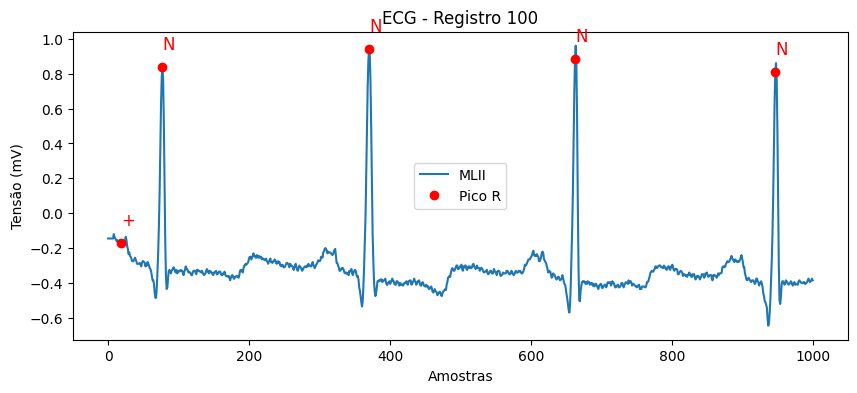

In [3]:
import matplotlib.pyplot as plt

# Plotar os primeiros 1000 pontos (~2.7 segundos) do primeiro canal
plt.figure(figsize=(10, 4))
plt.plot(sinal_ecg[:1000, 0], label=canais[0])

# Filtrar apenas os picos dentro da janela de 1000 pontos
picos_janela = [p for p in picos_amostras if p < 1000]
rotulos_janela = [rotulos[i] for i, p in enumerate(picos_amostras) if p < 1000]

# Marcar os picos no gráfico
plt.plot(picos_janela, sinal_ecg[picos_janela, 0], "ro", label="Pico R")
for x, rotulo in zip(picos_janela, rotulos_janela):
    plt.text(x, sinal_ecg[x, 0] + 0.1, rotulo, fontsize=12, color="red")

plt.title("ECG - Registro 100")
plt.xlabel("Amostras")
plt.ylabel("Tensão (mV)")
plt.legend()
plt.show()

# Análise DEPOIS do Tratamento

In [4]:
import pandas as pd

df = pd.read_csv('../database/processed/Dados_Arritmia_Renan.csv')

In [5]:
print(df.shape)
print(df.columns)
print(df['padrao_aami'].value_counts())
print(f'Qtd exames: {len(df['registro'].value_counts())}')

(101145, 306)
Index(['registro', 'ponto_0', 'ponto_1', 'ponto_2', 'ponto_3', 'ponto_4',
       'ponto_5', 'ponto_6', 'ponto_7', 'ponto_8',
       ...
       'ponto_295', 'ponto_296', 'ponto_297', 'ponto_298', 'ponto_299',
       'rr_pre', 'rr_pos', 'rr_relativo', 'padrao_aami', 'tipo'],
      dtype='str', length=306)
padrao_aami
N    90069
V     7480
S     2779
F      802
Q       15
Name: count, dtype: int64
Qtd exames: 44


In [6]:
# Quantidade de batimentos de cada tipo em cada conjunto (treino e teste)
print("Treino:")
print(df[df['tipo'] == 'treino']['padrao_aami'].value_counts())

print("\nTeste:")
print(df[df['tipo'] == 'teste']['padrao_aami'].value_counts())

Treino:
padrao_aami
N    44232
V     3220
S     1836
F      388
Q        7
Name: count, dtype: int64

Teste:
padrao_aami
N    45837
V     4260
S      943
F      414
Q        8
Name: count, dtype: int64


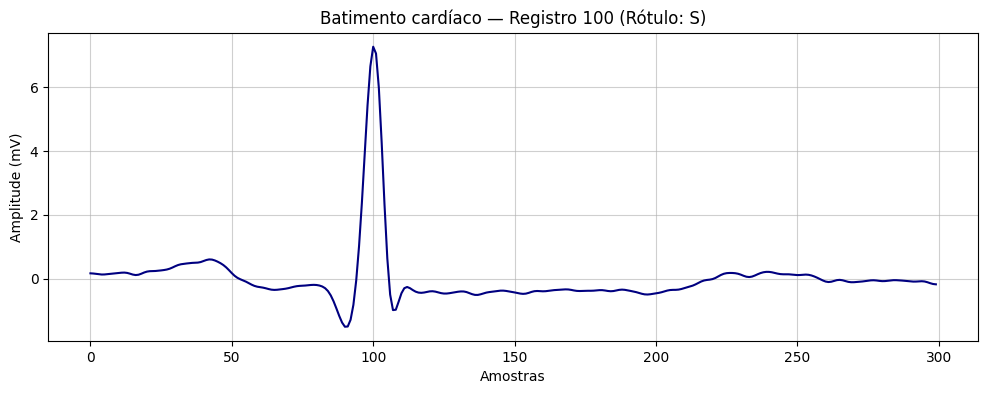

In [22]:
# Seleciona um batimento qualquer do dataframe
batimento = df.iloc[6]

colunas_sinal = [f'ponto_{i}' for i in range(300)]
sinal_batimento = batimento[colunas_sinal].to_numpy()

plt.figure(figsize=(12, 4))
plt.plot(sinal_batimento, color='navy')

plt.title(
    f"Batimento cardíaco — Registro {batimento['registro']} "
    f"(Rótulo: {batimento['padrao_aami']})"
)
plt.xlabel("Amostras")
plt.ylabel("Amplitude (mV)")
plt.grid(alpha=0.6)
plt.show()